# Do skin-marking shortcuts fool a melanoma classifier? Reproducing and fixing Winkler et al. (2019)

**Paper we're anchored on:** Winkler JK, et al. *Association Between Surgical Skin Markings in
Dermoscopic Images and Diagnostic Performance of a Deep Learning Convolutional Neural Network for
Melanoma Recognition.* JAMA Dermatology, 2019.

**Their finding:** on the same 130 lesions, a clinically-used CNN scored 95.7% sensitivity /
84.1% specificity on clean photos, but when a surgical ink marking was added to the same lesions,
specificity collapsed to 45.8% — the model started calling benign spots "melanoma" just because a
mark was present.

**Their gap:** they recommend avoiding markings in photos. They do not attempt to fix the model.

**Our plan:**
1. Train our own baseline CNN on ISIC-2017 (melanoma vs. nevus, matching their melanocytic-lesion
   comparison) and measure clean-image sensitivity/specificity.
2. Digitally add synthetic ink markings to the test set — validated as equivalent to real markings
   by the original paper (P = .78 between real vs. electronic markings) — and re-measure.
3. Confirm with Grad-CAM that the model is attending to the marking, not the lesion.
4. Fix it: retrain with counterfactual marking augmentation (add synthetic marks to *both* classes
   during training, at random, so the marking stops being a usable shortcut).
5. Re-run the exact same marked-image test on the fixed model and compare.

Runs on a single free-tier Colab GPU; no repo cloning needed, this is self-contained.


## 1. Setup

In [1]:
!pip install -q grad-cam opencv-python-headless pandas scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.manual_seed(0)
np.random.seed(0)

Device: cuda


## 2. Download ISIC-2017 (images + classification labels)

Reuses the same image/mask zips as before, plus the Part 3 classification ground-truth CSVs
(`melanoma` / `seborrheic_keratosis` columns; both 0 means benign nevus).

In [3]:
%%bash
set -e
mkdir -p /content/data
cd /content

for f in ISIC-2017_Training_Data ISIC-2017_Validation_Data ISIC-2017_Test_v2_Data; do
  wget -c -q "https://isic-archive.s3.amazonaws.com/challenges/2017/${f}.zip"
  unzip -q -o "${f}.zip" -d /content/data/
done

for f in ISIC-2017_Training_Part3_GroundTruth.csv ISIC-2017_Validation_Part3_GroundTruth.csv ISIC-2017_Test_v2_Part3_GroundTruth.csv; do
  wget -c -q "https://isic-archive.s3.amazonaws.com/challenges/2017/${f}" -O "/content/data/${f}" || \
    echo "WARNING: could not fetch ${f} from S3 -- download it manually from https://challenge.isic-archive.com/data/#2017 or Kaggle (search 'ISIC 2017') and place it in /content/data/"
done

echo "=== /content/data ==="
ls /content/data | grep -E "Data$|csv$"

=== /content/data ===
ISIC-2017_Test_v2_Data
ISIC-2017_Test_v2_Part3_GroundTruth.csv
ISIC-2017_Training_Data
ISIC-2017_Training_Part3_GroundTruth.csv
ISIC-2017_Validation_Data
ISIC-2017_Validation_Part3_GroundTruth.csv


In [4]:
# Sanity-check the label CSVs loaded correctly -- if this fails, the S3 fetch above
# probably failed and you need to grab the CSVs manually (see warning message above).
train_labels = pd.read_csv("/content/data/ISIC-2017_Training_Part3_GroundTruth.csv")
print(train_labels.shape)
train_labels.head()

(2000, 3)


,image_id,melanoma,seborrheic_keratosis
0,ISIC_0000000,0.0,0.0
1,ISIC_0000001,0.0,0.0
2,ISIC_0000002,1.0,0.0
3,ISIC_0000003,0.0,0.0
4,ISIC_0000004,1.0,0.0


## 3. Build the melanoma-vs-nevus dataset

Following the paper's own comparison (melanocytic lesions: melanoma vs. benign nevus), we drop
seborrheic keratosis images -- they're a different (non-melanocytic) lesion type and weren't part
of the original comparison.

In [5]:
def load_split(csv_path, img_dir):
    df = pd.read_csv(csv_path)
    # keep only melanoma vs. nevus (drop seborrheic keratosis rows)
    df = df[df["seborrheic_keratosis"] == 0].reset_index(drop=True)
    df["label"] = df["melanoma"].astype(int)  # 1 = melanoma, 0 = nevus
    df["path"] = df["image_id"].apply(lambda x: os.path.join(img_dir, f"{x}.jpg"))
    df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)
    return df[["image_id", "path", "label"]]

train_df = load_split(
    "/content/data/ISIC-2017_Training_Part3_GroundTruth.csv",
    "/content/data/ISIC-2017_Training_Data",
)
val_df = load_split(
    "/content/data/ISIC-2017_Validation_Part3_GroundTruth.csv",
    "/content/data/ISIC-2017_Validation_Data",
)
test_df = load_split(
    "/content/data/ISIC-2017_Test_v2_Part3_GroundTruth.csv",
    "/content/data/ISIC-2017_Test_v2_Data",
)

print("train:", len(train_df), "melanoma:", train_df.label.sum())
print("val:  ", len(val_df), "melanoma:", val_df.label.sum())
print("test: ", len(test_df), "melanoma:", test_df.label.sum())

train: 1746 melanoma: 374
val:   108 melanoma: 30
test:  510 melanoma: 117


## 4. The synthetic marking function

This mimics a surgical skin marker: a couple of thick, dark, slightly curved strokes near the
lesion, not covering the whole image. Applied at full resolution, before resizing.

[debug] image size=4288x2848, stroke thickness=45px, length=901px


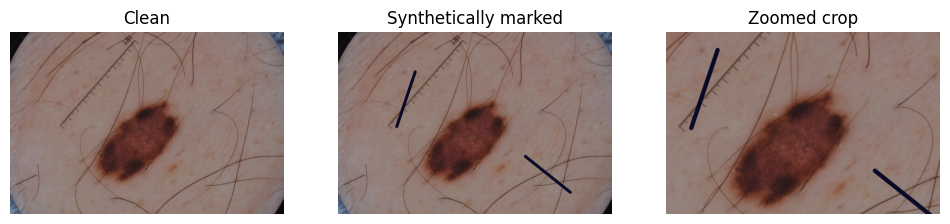

In [6]:
def add_synthetic_marking(pil_img, seed=None):
    """Draw fake surgical ink marks: bold, straight, high-contrast -- NOT hair-like."""
    rng = np.random.default_rng(seed)
    img = np.array(pil_img.convert("RGB")).copy()
    h, w = img.shape[:2]
    min_dim = min(h, w)

    mark_color = (10, 10, 40)  # near-black, deep ink
    n_strokes = rng.integers(1, 3)

    # thickness scales WITH the image so it's always visible, regardless of native resolution
    thickness = max(6, int(rng.uniform(0.012, 0.02) * min_dim))
    length = rng.uniform(0.18, 0.32) * min_dim

    for _ in range(n_strokes):
        cx = rng.integers(int(0.2 * w), int(0.8 * w))
        cy = rng.integers(int(0.2 * h), int(0.8 * h))
        angle = rng.uniform(0, 2 * np.pi)

        x1 = int(cx - length / 2 * np.cos(angle))
        y1 = int(cy - length / 2 * np.sin(angle))
        x2 = int(cx + length / 2 * np.cos(angle))
        y2 = int(cy + length / 2 * np.sin(angle))

        cv2.line(img, (x1, y1), (x2, y2), mark_color, thickness=int(thickness), lineType=cv2.LINE_8)

    print(f"[debug] image size={w}x{h}, stroke thickness={thickness}px, length={int(length)}px")
    return Image.fromarray(img)


# sanity check with a zoomed crop so display downsampling can't hide it
sample_img = Image.open(test_df.path.iloc[0])
marked = add_synthetic_marking(sample_img, seed=4)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_img); axes[0].set_title("Clean"); axes[0].axis("off")
axes[1].imshow(marked); axes[1].set_title("Synthetically marked"); axes[1].axis("off")

w, h = marked.size
crop = marked.crop((int(0.15*w), int(0.15*h), int(0.85*w), int(0.85*h)))
axes[2].imshow(crop); axes[2].set_title("Zoomed crop"); axes[2].axis("off")
plt.show()

## 5. Dataset / DataLoader

In [7]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class ISICMelanomaDataset(Dataset):
    """
    mark_prob: probability of adding a synthetic marking to a given image.
    mark_target: None (mark_prob applies to everyone -- used for the "always marked"
                 eval set), or a specific label int (only mark examples of that label --
                 used to reproduce the paper's original marking bias during a *biased*
                 training run, if you want to demonstrate the shortcut being learned
                 from scratch as well as just tested at eval time).
    """
    def __init__(self, df, transform, mark_prob=0.0, mark_target=None, seed=0):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.mark_prob = mark_prob
        self.mark_target = mark_target
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.path).convert("RGB")

        should_mark = self.rng.random() < self.mark_prob
        if self.mark_target is not None:
            should_mark = should_mark and (row.label == self.mark_target)

        if should_mark:
            img = add_synthetic_marking(img, seed=int(self.rng.integers(0, 1_000_000)))

        img = self.transform(img)
        return img, torch.tensor(row.label, dtype=torch.long)


BATCH_SIZE = 32
NUM_WORKERS = 2

train_ds = ISICMelanomaDataset(train_df, train_aug_transform, mark_prob=0.0)
val_ds = ISICMelanomaDataset(val_df, base_transform, mark_prob=0.0)
test_clean_ds = ISICMelanomaDataset(test_df, base_transform, mark_prob=0.0)
test_marked_ds = ISICMelanomaDataset(test_df, base_transform, mark_prob=1.0)  # ALL marked

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_clean_loader = DataLoader(test_clean_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_marked_loader = DataLoader(test_marked_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

## 6. Baseline model: fine-tuned ResNet18

In [8]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model.to(device)


def class_weighted_loss(df):
    counts = df.label.value_counts().sort_index()  # index 0=nevus, 1=melanoma
    weights = torch.tensor(1.0 / counts.values, dtype=torch.float32)
    weights = weights / weights.sum() * 2  # normalize
    return nn.CrossEntropyLoss(weight=weights.to(device))


def train_model(model, train_loader, val_loader, train_df_for_weights, epochs=8, lr=1e-4):
    criterion = class_weighted_loss(train_df_for_weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                preds = model(imgs).argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        print(f"Epoch {epoch+1}/{epochs} | train_loss={total_loss/len(train_loader.dataset):.4f} "
              f"| val_acc={correct/total:.4f}")

    return model


baseline_model = build_model()
baseline_model = train_model(baseline_model, train_loader, val_loader, train_df, epochs=8)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 129MB/s]


Epoch 1/8 | train_loss=0.6050 | val_acc=0.7130
Epoch 2/8 | train_loss=0.4574 | val_acc=0.6852
Epoch 3/8 | train_loss=0.3621 | val_acc=0.7593
Epoch 4/8 | train_loss=0.3029 | val_acc=0.7500
Epoch 5/8 | train_loss=0.2245 | val_acc=0.7778
Epoch 6/8 | train_loss=0.1884 | val_acc=0.8426
Epoch 7/8 | train_loss=0.1429 | val_acc=0.8704
Epoch 8/8 | train_loss=0.1308 | val_acc=0.8148


## 7. Evaluate: clean vs. marked (this reproduces the paper's core test)

In [9]:
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else float("nan")  # melanoma recall
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")  # nevus recall
    return {"sensitivity": sensitivity, "specificity": specificity, "confusion_matrix": cm}


clean_results = evaluate(baseline_model, test_clean_loader)
marked_results = evaluate(baseline_model, test_marked_loader)

print("=== Baseline model, CLEAN test images ===")
print(f"Sensitivity: {clean_results['sensitivity']:.3f}  Specificity: {clean_results['specificity']:.3f}")
print("\n=== Baseline model, MARKED test images ===")
print(f"Sensitivity: {marked_results['sensitivity']:.3f}  Specificity: {marked_results['specificity']:.3f}")
print("\nFor reference, Winkler et al. 2019 reported:")
print("  Clean:  sensitivity 0.957, specificity 0.841")
print("  Marked: sensitivity 1.000, specificity 0.458")

[debug] image size=3008x2000, stroke thickness=30px, length=402px
[debug] image size=4288x2848, stroke thickness=42px, length=573px
[debug] image size=3872x2592, stroke thickness=46px, length=745px
[debug] image size=3008x2000, stroke thickness=35px, length=574px
[debug] image size=3008x2000, stroke thickness=30px, length=432px
[debug] image size=3008x2000, stroke thickness=30px, length=432px
[debug] image size=3008x2000, stroke thickness=34px, length=506px
[debug] image size=3008x2000, stroke thickness=34px, length=506px
[debug] image size=3008x2000, stroke thickness=28px, length=559px
[debug] image size=3008x2000, stroke thickness=28px, length=559px
[debug] image size=3872x2592, stroke thickness=32px, length=819px
[debug] image size=3008x2000, stroke thickness=25px, length=632px
[debug] image size=3872x2592, stroke thickness=43px, length=594px
[debug] image size=4288x2848, stroke thickness=48px, length=653px
[debug] image size=3008x2000, stroke thickness=27px, length=468px
[debug] im

In [10]:
class BiasedMarkDataset(ISICMelanomaDataset):
    """Marks melanoma images often, nevus images rarely -- mimicking the real-world
    correlation between clinical suspicion (marking) and malignant diagnosis."""
    def __init__(self, df, transform, prob_by_label, seed=0):
        super().__init__(df, transform, mark_prob=0.0, seed=seed)
        self.prob_by_label = prob_by_label  # e.g. {1: 0.75, 0: 0.05}

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row.path).convert("RGB")
        p = self.prob_by_label[int(row.label)]
        if self.rng.random() < p:
            img = add_synthetic_marking(img, seed=int(self.rng.integers(0, 1_000_000)))
        img = self.transform(img)
        return img, torch.tensor(row.label, dtype=torch.long)


biased_train_ds = BiasedMarkDataset(train_df, train_aug_transform, prob_by_label={1: 0.75, 0: 0.05})
biased_train_loader = DataLoader(biased_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

biased_model = build_model()
biased_model = train_model(biased_model, biased_train_loader, val_loader, train_df, epochs=8)

biased_clean = evaluate(biased_model, test_clean_loader)
biased_marked = evaluate(biased_model, test_marked_loader)
print(f"Biased model | Clean: sens={biased_clean['sensitivity']:.3f} spec={biased_clean['specificity']:.3f}")
print(f"Biased model | Marked: sens={biased_marked['sensitivity']:.3f} spec={biased_marked['specificity']:.3f}")

[debug] image size=1024x768, stroke thickness=11px, length=154px
[debug] image size=3024x2016, stroke thickness=35px, length=579px
[debug] image size=767x576, stroke thickness=10px, length=161px
[debug] image size=3008x2000, stroke thickness=30px, length=432px
[debug] image size=3008x2000, stroke thickness=29px, length=419px
[debug] image size=4288x2848, stroke thickness=38px, length=588px
[debug] image size=1504x1129, stroke thickness=19px, length=285px
[debug] image size=1024x768, stroke thickness=9px, length=211px
[debug] image size=6627x4459, stroke thickness=58px, length=998px
[debug] image size=1024x768, stroke thickness=11px, length=226px
[debug] image size=4288x2848, stroke thickness=48px, length=717px
[debug] image size=4288x2848, stroke thickness=45px, length=673px
[debug] image size=4288x2848, stroke thickness=48px, length=650px
[debug] image size=4288x2848, stroke thickness=42px, length=573px
[debug] image size=6688x4459, stroke thickness=53px, length=1103px
[debug] image s

## 8. Grad-CAM: is the model looking at the mark?

Run this on a few melanoma-vs-nevus examples where the *marked* prediction flipped
relative to the *clean* prediction -- those are your most convincing illustrative cases.

[debug] image size=4288x2848, stroke thickness=44px, length=854px
[debug] image size=4288x2848, stroke thickness=54px, length=821px
[debug] image size=4288x2848, stroke thickness=47px, length=716px
[debug] image size=4288x2848, stroke thickness=55px, length=570px
[debug] image size=4288x2848, stroke thickness=53px, length=836px
[debug] image size=3008x2000, stroke thickness=31px, length=600px
[debug] image size=3008x2000, stroke thickness=38px, length=577px
Found: image_id=ISIC_0012095, mark seed=7
P(nevus), P(melanoma) on this marked image:
  baseline: [0.9642968  0.03570319]
  biased:   [0.26352093 0.73647904]
  fixed:    [0.9855209  0.01447915]


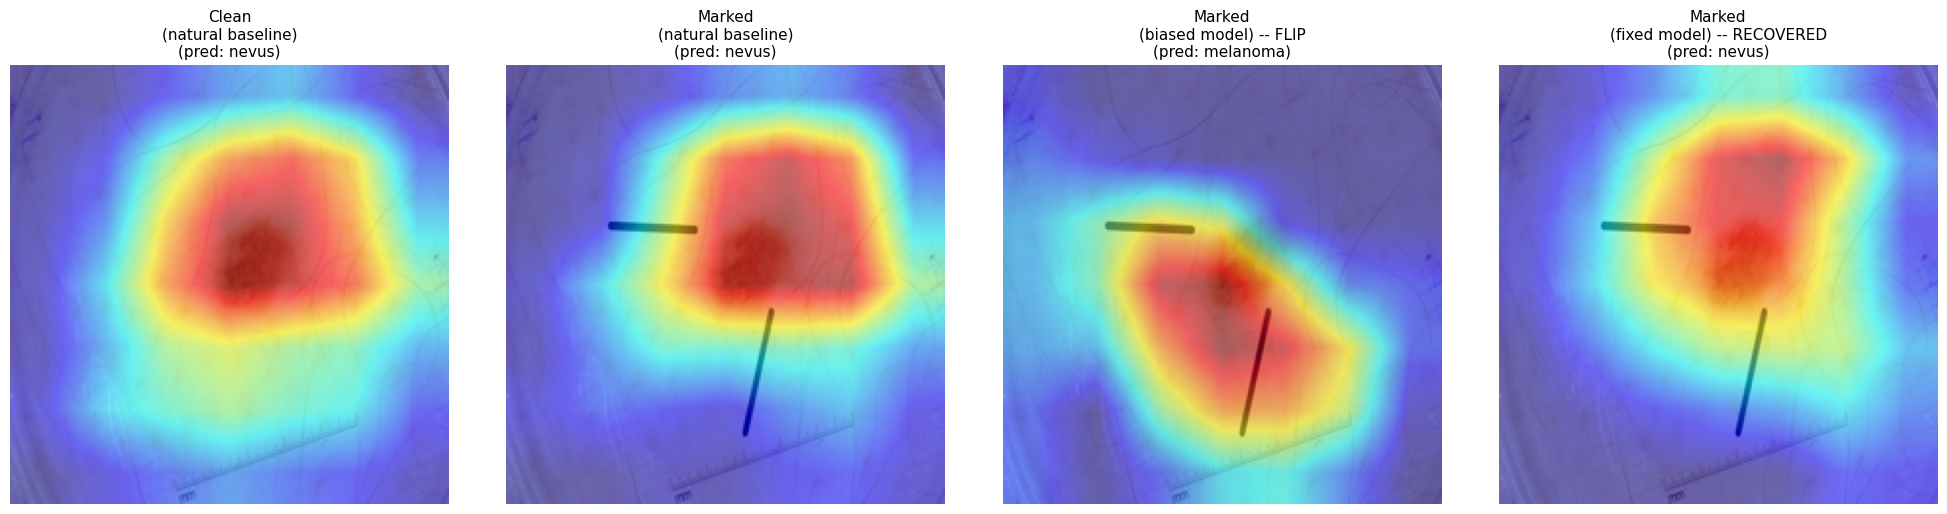

In [20]:
import torch.nn.functional as F
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


def make_cam(model):
    return GradCAM(model=model, target_layers=[model.layer4[-1]])


def get_probs(model, img_t):
    with torch.no_grad():
        return F.softmax(model(img_t), dim=1)[0].cpu().numpy()  # [p_nevus, p_melanoma]


def get_gradcam_vis(pil_img, model, cam):
    """Returns the CAM overlay + predicted class, without plotting."""
    img_t = base_transform(pil_img).unsqueeze(0).to(device)
    pred_class = model(img_t).argmax(dim=1).item()
    grayscale_cam = cam(input_tensor=img_t, targets=None)[0]
    rgb_img = np.array(pil_img.resize((IMG_SIZE, IMG_SIZE))) / 255.0
    vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    return vis, pred_class


cam_baseline = make_cam(baseline_model)
cam_biased = make_cam(biased_model)
cam_fixed = make_cam(fixed_model)

# find a clean contrastive example: baseline correct, biased WRONG, fixed correct again
gotcha_row = None
for _, row in test_df[test_df.label == 0].iterrows():
    img = Image.open(row.path).convert("RGB")
    for seed in [42, 7, 99, 1, 13]:
        marked_candidate = add_synthetic_marking(img, seed=seed)
        img_t = base_transform(marked_candidate).unsqueeze(0).to(device)

        pred_baseline = baseline_model(img_t).argmax(dim=1).item()
        pred_biased = biased_model(img_t).argmax(dim=1).item()
        pred_fixed = fixed_model(img_t).argmax(dim=1).item()

        if pred_baseline == 0 and pred_biased == 1 and pred_fixed == 0:
            gotcha_row = row
            gotcha_marked = marked_candidate
            gotcha_clean = img
            break
    if gotcha_row is not None:
        break

if gotcha_row is None:
    print("No clean contrastive example found -- widen the seed list, or fall back to")
    print("the first nevus in test_df without the pred_baseline==0 requirement")
else:
    print(f"Found: image_id={gotcha_row.image_id}, mark seed={seed}")
    img_t = base_transform(gotcha_marked).unsqueeze(0).to(device)
    print("P(nevus), P(melanoma) on this marked image:")
    print("  baseline:", get_probs(baseline_model, img_t))
    print("  biased:  ", get_probs(biased_model, img_t))
    print("  fixed:   ", get_probs(fixed_model, img_t))

    panels = [
        ("Clean\n(natural baseline)", gotcha_clean, baseline_model, cam_baseline),
        ("Marked\n(natural baseline)", gotcha_marked, baseline_model, cam_baseline),
        ("Marked\n(biased model) -- FLIP", gotcha_marked, biased_model, cam_biased),
        ("Marked\n(fixed model) -- RECOVERED", gotcha_marked, fixed_model, cam_fixed),
    ]

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    for ax, (title, img, model, cam) in zip(axes, panels):
        vis, pred = get_gradcam_vis(img, model, cam)
        label = "melanoma" if pred == 1 else "nevus"
        ax.imshow(vis)
        ax.set_title(f"{title}\n(pred: {label})", fontsize=11)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("/content/gradcam_comparison.png", dpi=200, bbox_inches="tight")
    plt.show()

[debug] image size=4288x2848, stroke thickness=44px, length=854px
[debug] image size=4288x2848, stroke thickness=54px, length=821px
[debug] image size=4288x2848, stroke thickness=47px, length=716px
[debug] image size=3008x2000, stroke thickness=31px, length=600px
[debug] image size=3008x2000, stroke thickness=38px, length=577px
Found: image_id=ISIC_0012095, mark seed=7
P(nevus), P(melanoma) on this marked image:
  baseline: [0.9642968  0.03570319]
  biased:   [0.26352093 0.73647904]
  fixed:    [0.9855209  0.01447915]


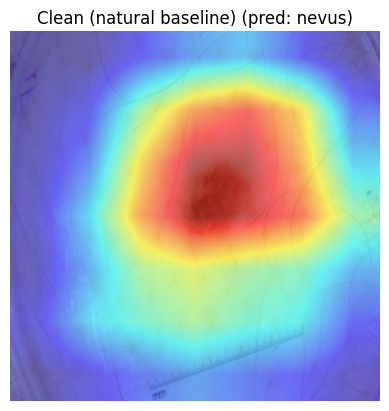

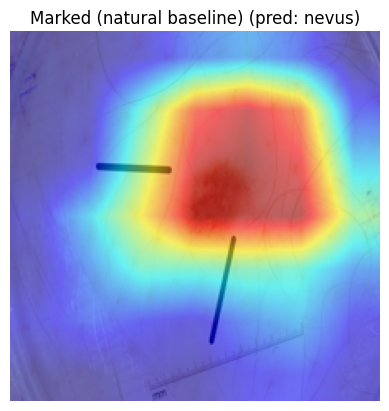

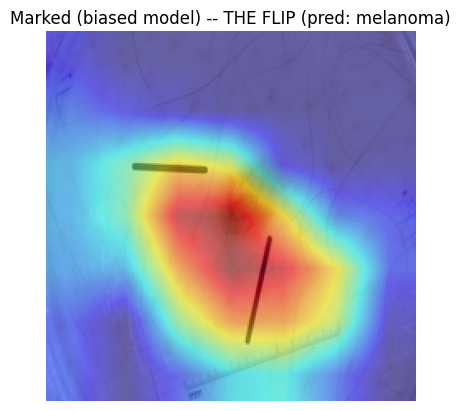

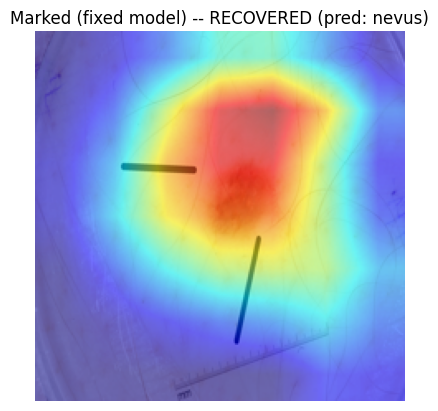

In [19]:
import torch.nn.functional as F

def get_probs(model, img_t):
    with torch.no_grad():
        return F.softmax(model(img_t), dim=1)[0].cpu().numpy()  # [p_nevus, p_melanoma]

gotcha_row = None
for _, row in test_df[test_df.label == 0].iterrows():
    img = Image.open(row.path).convert("RGB")
    for seed in [42, 7, 99]:
        marked_candidate = add_synthetic_marking(img, seed=seed)
        img_t = base_transform(marked_candidate).unsqueeze(0).to(device)

        pred_baseline = baseline_model(img_t).argmax(dim=1).item()
        pred_biased = biased_model(img_t).argmax(dim=1).item()
        pred_fixed = fixed_model(img_t).argmax(dim=1).item()

        # the clean contrastive case: baseline correct, biased WRONG, fixed correct again
        if pred_baseline == 0 and pred_biased == 1 and pred_fixed == 0:
            gotcha_row = row
            gotcha_marked = marked_candidate
            gotcha_clean = img
            break
    if gotcha_row is not None:
        break

if gotcha_row is None:
    print("No clean contrastive example found in this pass -- widen the seed list or")
    print("relax the condition (e.g. drop the pred_baseline==0 requirement)")
else:
    print(f"Found: image_id={gotcha_row.image_id}, mark seed={seed}")
    img_t = base_transform(gotcha_marked).unsqueeze(0).to(device)
    print("P(nevus), P(melanoma) on this marked image:")
    print("  baseline:", get_probs(baseline_model, img_t))
    print("  biased:  ", get_probs(biased_model, img_t))
    print("  fixed:   ", get_probs(fixed_model, img_t))

    show_gradcam(gotcha_clean, baseline_model, cam_baseline, title="Clean (natural baseline)")
    show_gradcam(gotcha_marked, baseline_model, cam_baseline, title="Marked (natural baseline)")
    show_gradcam(gotcha_marked, biased_model, cam_biased, title="Marked (biased model) -- THE FLIP")
    show_gradcam(gotcha_marked, fixed_model, cam_fixed, title="Marked (fixed model) -- RECOVERED")

## 9. The fix: counterfactual marking augmentation

During training, add synthetic marks to *both* classes at random with equal probability, so the
marking stops carrying any information about the label. If the model can no longer use "is there
a mark" as a predictive feature, it's forced to actually look at the lesion.

In [15]:
fixed_train_ds = ISICMelanomaDataset(train_df, train_aug_transform, mark_prob=0.5, mark_target=None)
fixed_train_loader = DataLoader(fixed_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

fixed_model = build_model()
fixed_model = train_model(fixed_model, fixed_train_loader, val_loader, train_df, epochs=8)

Streaming output truncated to the last 5000 lines.
[debug] image size=3024x2016, stroke thickness=33px, length=457px
[debug] image size=962x674, stroke thickness=12px, length=203px
[debug] image size=1043x705, stroke thickness=12px, length=218px
[debug] image size=4288x2848, stroke thickness=48px, length=742px
[debug] image size=1024x768, stroke thickness=15px, length=162px
[debug] image size=2048x1536, stroke thickness=22px, length=288px
[debug] image size=838x614, stroke thickness=12px, length=118px
[debug] image size=949x626, stroke thickness=10px, length=120px
[debug] image size=1504x1129, stroke thickness=15px, length=255px
[debug] image size=3008x2000, stroke thickness=27px, length=480px
[debug] image size=3024x2016, stroke thickness=33px, length=406px
[debug] image size=3008x2000, stroke thickness=37px, length=403px
[debug] image size=1024x768, stroke thickness=12px, length=209px
[debug] image size=3008x2000, stroke thickness=25px, length=494px
[debug] image size=1024x768, strok

## 10. Re-run the exact same test on the fixed model

In [16]:
fixed_clean = evaluate(fixed_model, test_clean_loader)
fixed_marked = evaluate(fixed_model, test_marked_loader)

results = [
    ("Natural baseline", clean_results, marked_results),
    ("Biased (injected)", biased_clean, biased_marked),
    ("Fixed", fixed_clean, fixed_marked),
]

print("=== Natural baseline vs Biased (the failure) vs Fixed (the repair) ===\n")
print(f"{'':20s} {'Clean sens':>11s} {'Clean spec':>11s} {'Marked sens':>12s} {'Marked spec':>12s}")
for name, clean, marked in results:
    print(f"{name:20s} {clean['sensitivity']:11.3f} {clean['specificity']:11.3f} "
          f"{marked['sensitivity']:12.3f} {marked['specificity']:12.3f}")

print("\nWhat you want to see:")
print("- Biased row: big clean->marked specificity drop (this is the reproduced failure)")
print("- Fixed row, clean columns: close to Biased's clean numbers (didn't lose real accuracy)")
print("- Fixed row, marked spec: much closer to its own clean spec than Biased's was --")
print("  i.e. the clean->marked gap should be small again, like the natural baseline's")

[debug] image size=3008x2000, stroke thickness=30px, length=402px
[debug] image size=4288x2848, stroke thickness=42px, length=573px
[debug] image size=3872x2592, stroke thickness=46px, length=745px
[debug] image size=3008x2000, stroke thickness=35px, length=574px
[debug] image size=3008x2000, stroke thickness=30px, length=432px
[debug] image size=3008x2000, stroke thickness=30px, length=432px
[debug] image size=3008x2000, stroke thickness=34px, length=506px
[debug] image size=3008x2000, stroke thickness=34px, length=506px
[debug] image size=3008x2000, stroke thickness=28px, length=559px
[debug] image size=3008x2000, stroke thickness=28px, length=559px
[debug] image size=3872x2592, stroke thickness=32px, length=819px
[debug] image size=3008x2000, stroke thickness=25px, length=632px
[debug] image size=3872x2592, stroke thickness=43px, length=594px
[debug] image size=4288x2848, stroke thickness=48px, length=653px
[debug] image size=3008x2000, stroke thickness=27px, length=468px
[debug] im

In [ ]:
show_gradcam(marked_img, fixed_model, cam, title="Marked nevus (fixed model)")

# 11. Saving all models to Drive

In [ ]:
torch.save(baseline_model.state_dict(), "/content/drive/MyDrive/shortcut_study/baseline_model.pt")
torch.save(biased_model.state_dict(), "/content/drive/MyDrive/shortcut_study/biased_model.pt")
torch.save(fixed_model.state_dict(), "/content/drive/MyDrive/shortcut_study/fixed_model.pt")

## 12. Writing it up

Lead with:
1. The Grad-CAM pair (clean vs. marked) from the baseline model — the "gotcha" image.
2. The 4-number table from section 10 — this is your quantified before/after.
3. State the comparison to Winkler et al.'s numbers explicitly, and be precise: this is a
   *different* model (ResNet18, not their market-approved CNN) and a *different* dataset split
   (ISIC-2017, not their 130-lesion set) — you're testing whether the same failure mode
   reproduces on independent data/model, not claiming to replicate their exact numbers.
4. Be honest that this is a synthetic-marking study — validated as consistent with real markings
   by the original paper, but still synthetic in your case (you don't have real marked photos).

This is a sensitive medical-AI topic, so keep every claim scoped to exactly what you tested —
this dataset, this model, this specific bias — rather than broad statements about medical AI
safety in general. That precision is what makes it read as credible.
